In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
%matplotlib inline

In [2]:
#prepend /Users/antoinekoehl/Software/tecantaloupe to the path
import sys
sys.path.append('/Users/antoinekoehl/Software/tecantaloupe')
from growth.plate_spec import PlateSpec
from growth.plate_time_course_parser import SavageLabM1000Excel


## Replicate 20250220

I replicated the experiment

In [3]:
plate_spec_file = '20250220_plate_spec.csv'
ps = PlateSpec.FromFile(plate_spec_file)
name_mapping = ps.well_to_name_mapping()

parser = SavageLabM1000Excel()
timecourse = parser.ParseFromFilename('20250220_Results_Autosave.xlsx')

blanked = timecourse.blank()
smoothed = blanked.smooth()

OD_data = smoothed.data_for_label('A600')
means = smoothed.mean_by_name(ps)
sems = smoothed.sem_by_name(ps)

mean_OD = means.data_for_label('A600')
sems_OD = sems.data_for_label('A600')

/Users/antoinekoehl/Software/tecantaloupe/growth/plate_time_course.py:138: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for key, values in corrected_df.iteritems():
/Users/antoinekoehl/Software/tecantaloupe/growth/plate_time_course.py:281: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for key, row in smoothed.iteritems():
/Users/antoinekoehl/Software/tecantaloupe/growth/plate_time_course.py:379: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sem is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  group_sems = grouped.sem()


In [4]:
lag_times = means.LagTime(density_label='A600')
growth_rates = means.MaxGrowthRates(density_label='A600')
yields = means.GrowthYield(density_label='A600')

/Users/antoinekoehl/Software/tecantaloupe/growth/plate_time_course.py:427: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for k, idx in min_idxs.iteritems():
/Users/antoinekoehl/Software/tecantaloupe/growth/plate_time_course.py:432: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for k, max_od in max_od.iteritems():
/Users/antoinekoehl/miniconda3/envs/tecanteloupe/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/antoinekoehl/Software/tecantaloupe/growth/plate_time_course.py:509: RuntimeWarning: All-NaN slice encountered
  if np.nanmin(local_data) < log_lb:


In [5]:
pos_set = [c for c in mean_OD.columns if c.startswith('WT') or c.startswith('HCA')]
neg_set = [c for c in mean_OD.columns if c.startswith('D152N')]
exp_set = [c for c in mean_OD.columns if c.startswith('seq')]

pos = [p for p in pos_set if '200' in p]
neg = [p for p in neg_set if '200' in p]
exp = [p for p in exp_set if '200' in p]

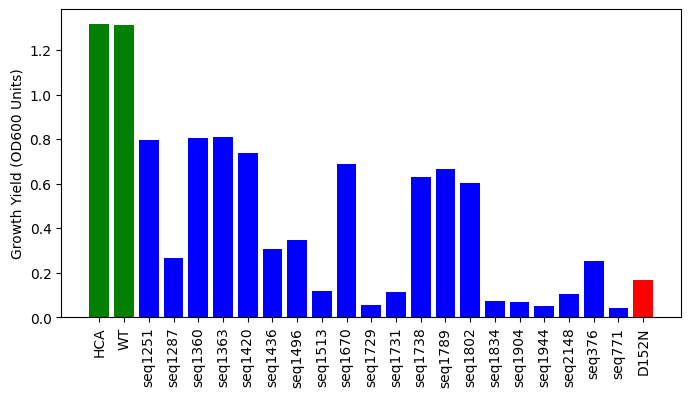

In [6]:
labels = sorted(pos) + sorted(exp) + sorted(neg)
colors = ['green'] * len(pos) + ['blue'] * len(exp) + ['red'] * len(neg)
axis_labels = [l[:l.find('+')].replace('_unsorted','').replace('_sorted','') for l in labels]

ylds = [yields[l] for l in labels]

figure = plt.figure(figsize=(8,4))
xs = np.arange(len(ylds))
plt.bar(xs, ylds, color=colors)
plt.ylabel('Growth Yield (OD600 Units)')
plt.xticks(xs, axis_labels, rotation=90)
plt.show()

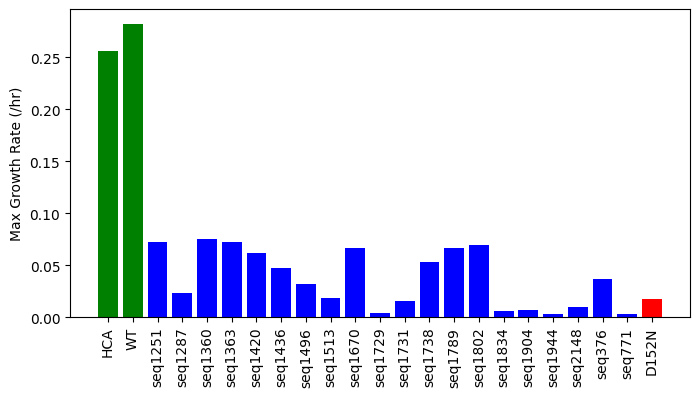

In [7]:
labels = sorted(pos) + sorted(exp) + sorted(neg)
grs = [growth_rates[l] for l in labels]

figure = plt.figure(figsize=(8,4))
xs = np.arange(len(grs))
plt.bar(xs, grs, color=colors)
plt.ylabel('Max Growth Rate (/hr)')
plt.xticks(xs, axis_labels, rotation=90)
plt.show()

In [8]:
exp_to_plot = list(filter(lambda x: any([y in x for y in ['1789', '1802', '1363', '1251', '1360', '1944', '1729', '1670']]), exp))

(0.4, 0.7607843137254902, 0.6470588235294118)
(0.9882352941176471, 0.5529411764705883, 0.3843137254901961)
(0.5529411764705883, 0.6274509803921569, 0.796078431372549)
(0.9058823529411765, 0.5411764705882353, 0.7647058823529411)
(0.6509803921568628, 0.8470588235294118, 0.32941176470588235)
(1.0, 0.8509803921568627, 0.1843137254901961)
(0.8980392156862745, 0.7686274509803922, 0.5803921568627451)
(0.7019607843137254, 0.7019607843137254, 0.7019607843137254)


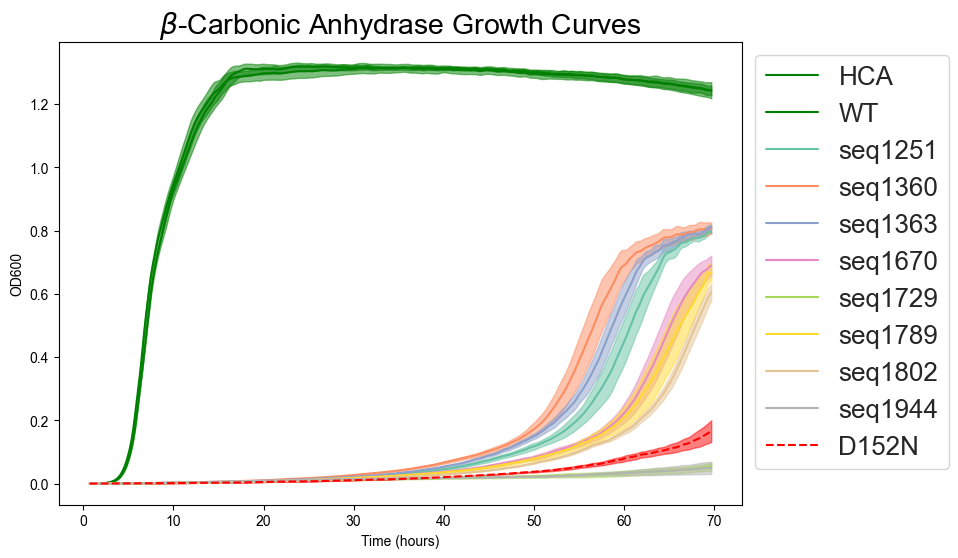

In [9]:
colors = sns.color_palette('Set2')
time_h = mean_OD.time_s / (60*60)
fig, axs = plt.subplots(figsize=(10,6))

sns.set_theme(style='white', font_scale=1.7)

for i, c in enumerate(sorted(pos)):
    label = c.replace('_unsorted', '').replace('_sorted', '').replace('+ 200 ATC', '')
    color = 'green'
    plt.fill_between(time_h, mean_OD[c] - sems_OD[c], mean_OD[c] + sems_OD[c],
                     color=color, alpha=0.5)
    plt.plot(time_h, mean_OD[c], label=label, color=color, figure=fig)


for i, c in enumerate(exp_to_plot):
    label = c.replace('_unsorted', '').replace('_sorted', '').replace('+ 200 ATC', '')
    color = colors[i % len(colors)]
    print(color)
    plt.fill_between(time_h, mean_OD[c] - sems_OD[c], mean_OD[c] + sems_OD[c],
                     color=color, alpha=0.5)
    plt.plot(time_h, mean_OD[c], label=label, color=color, figure=fig)

for i, c in enumerate(sorted(neg)):
    label = c.replace('_unsorted', '').replace('_sorted', '').replace('+ 200 ATC', '')
    color = 'red'
    plt.fill_between(time_h, mean_OD[c] - sems_OD[c], mean_OD[c] + sems_OD[c],
                     color=color, alpha=0.5)
    plt.plot(time_h, mean_OD[c], label=label, color=color, ls='--', figure=fig)

plt.xlabel('Time (hours)')
plt.ylabel('OD600')
plt.title(r'$\beta$-Carbonic Anhydrase Growth Curves')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig('Growth_Curves.pdf')
plt.savefig('Growth_Curves.png')